# Лабораторная работа 4 — Визуализация данных

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** Matplotlib, Seaborn, Plotly, Pandas

## Цель работы

Освоить основные инструменты визуализации данных в Python — библиотеки Matplotlib, Seaborn и Plotly — и применить их для разведочного анализа (EDA) аудиодатасета GTZAN.

## Теоретическое введение

### Разведочный анализ данных (EDA)

**Разведочный анализ данных** (Exploratory Data Analysis, EDA) — это подход к анализу наборов данных, целью которого является выявление основных характеристик данных, обнаружение закономерностей, аномалий и проверка предположений с помощью статистических методов и визуализации. EDA является обязательным этапом любого проекта в области машинного обучения и data science.

Основные цели EDA:
- **Понимание структуры данных** — типы переменных, размерность, наличие пропусков
- **Выявление аномалий и выбросов** — значения, значительно отклоняющиеся от основной массы данных
- **Идентификация связей и корреляций** — взаимозависимости между признаками
- **Подготовка данных** — формирование гипотез для дальнейшего моделирования

### Типы визуализаций и их назначение

| Тип графика | Назначение | Когда использовать |
|------------|-----------|--------------------|
| **Scatter plot** | Отображение связи между двумя переменными | Поиск корреляций, кластеров |
| **Гистограмма** | Распределение одной переменной | Оценка формы распределения, модальности |
| **Box plot** | Статистическое описание + выбросы | Сравнение распределений между группами |
| **Heatmap** | Матрица зависимостей | Корреляционный анализ всех пар признаков |
| **Violin plot** | Распределение + плотность | Более детальное сравнение групп, чем box plot |
| **Pair plot** | Все парные зависимости | Обзорный анализ небольшого числа признаков |
| **Bar chart** | Сравнение категорий | Средние значения, частоты по группам |
| **Pie chart** | Доли целого | Пропорции категорий в датасете |

### Библиотеки визуализации в Python

**Matplotlib** — базовая библиотека визуализации. Основана на концепции объектов Figure (полотно) и Axes (области рисования). Предоставляет полный контроль над каждым элементом графика, но требует больше кода для красивого оформления.

**Seaborn** — высокоуровневая надстройка над Matplotlib. Предоставляет удобные функции для статистической визуализации: heatmap, pairplot, violinplot, displot. Автоматически применяет эстетичные стили.

**Plotly** — библиотека для создания интерактивных графиков. Графики поддерживают hover-подсказки, масштабирование, панорамирование. Особенно полезна для презентаций и дашбордов.

### Корреляция и тепловая карта

**Коэффициент корреляции Пирсона** измеряет линейную зависимость между двумя переменными. Значения от -1 (полная отрицательная корреляция) до +1 (полная положительная корреляция), 0 — отсутствие линейной связи. Тепловая карта корреляционной матрицы позволяет визуально обнаружить сильно и слабо связанные признаки.

### Выбросы и метод IQR

**Выброс** — наблюдение, значительно отличающееся от остальных данных. Для обнаружения выбросов используется **метод межквартильного размаха (IQR)**:
- $IQR = Q_3 - Q_1$
- Нижняя граница: $Q_1 - 1.5 \cdot IQR$
- Верхняя граница: $Q_3 + 1.5 \cdot IQR$

Значения за пределами этих границ считаются выбросами и отображаются на boxplot отдельными точками.

## Загрузка и описание данных

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Библиотеки загружены')

Библиотеки загружены


In [173]:
df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 1000 строк, 60 столбцов


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

In [175]:
# Числовые признаки (исключаем filename и label)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('length')  # length одинаковый для всех, неинформативен
print(f'Числовых признаков для анализа: {len(numeric_cols)}')
df[numeric_cols].describe().round(3)

Числовых признаков для анализа: 57


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,...,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.379,0.086,0.131,0.003,2201.781,469691.575,2242.541,137079.155,4571.549,1844345.043,...,1.148,60.731,-3.966,62.634,0.508,63.713,-2.329,66.232,-1.095,70.126
std,0.082,0.008,0.066,0.004,715.961,400899.517,526.316,96455.666,1574.792,1425084.588,...,4.579,33.782,4.550,33.479,3.869,34.402,3.756,37.175,3.837,45.229
min,0.172,0.045,0.005,0.000,570.040,7911.251,898.066,10787.185,749.141,14686.119,...,-15.694,9.169,-17.235,13.932,-11.964,15.421,-18.502,13.488,-19.930,7.957
25%,0.320,0.082,0.087,0.001,1627.697,184350.530,1907.241,67376.554,3380.070,772731.231,...,-1.863,40.376,-7.207,40.831,-2.007,41.884,-4.663,41.710,-3.369,42.373
50%,0.383,0.087,0.122,0.002,2209.263,338486.153,2221.393,111977.548,4658.524,1476114.872,...,1.213,52.325,-4.066,54.718,0.670,54.805,-2.394,57.423,-1.166,59.186
75%,0.436,0.091,0.176,0.004,2691.295,612147.935,2578.470,182371.577,5533.810,2555261.803,...,4.360,71.692,-0.839,75.041,3.119,75.386,0.151,78.626,1.313,85.375
max,0.664,0.108,0.398,0.028,4435.244,3036843.062,3509.646,694784.812,8677.673,8660900.484,...,13.457,392.932,11.483,406.059,15.388,332.905,14.695,393.162,15.370,506.065


Датасет GTZAN содержит 1000 аудиозаписей 10 музыкальных жанров (по 100 записей на жанр). Для каждой записи извлечены 57 числовых аудиопризнаков: хроматограммы, спектральные характеристики, MFCC-коэффициенты и другие.

---
## 1. Визуализация с помощью Matplotlib

Matplotlib — это фундаментальная библиотека визуализации в Python. Она основана на иерархии объектов: **Figure** (полотно) содержит один или несколько объектов **Axes** (области рисования), каждый из которых имеет оси, заголовок, легенду и графические элементы.

### 1.1. Scatter plot — зависимость спектральных признаков

Диаграмма рассеяния позволяет визуально оценить связь между двумя числовыми переменными. Построим scatter plot для spectral_centroid_mean и rolloff_mean — оба характеризуют «яркость» звука, и мы ожидаем увидеть положительную корреляцию.

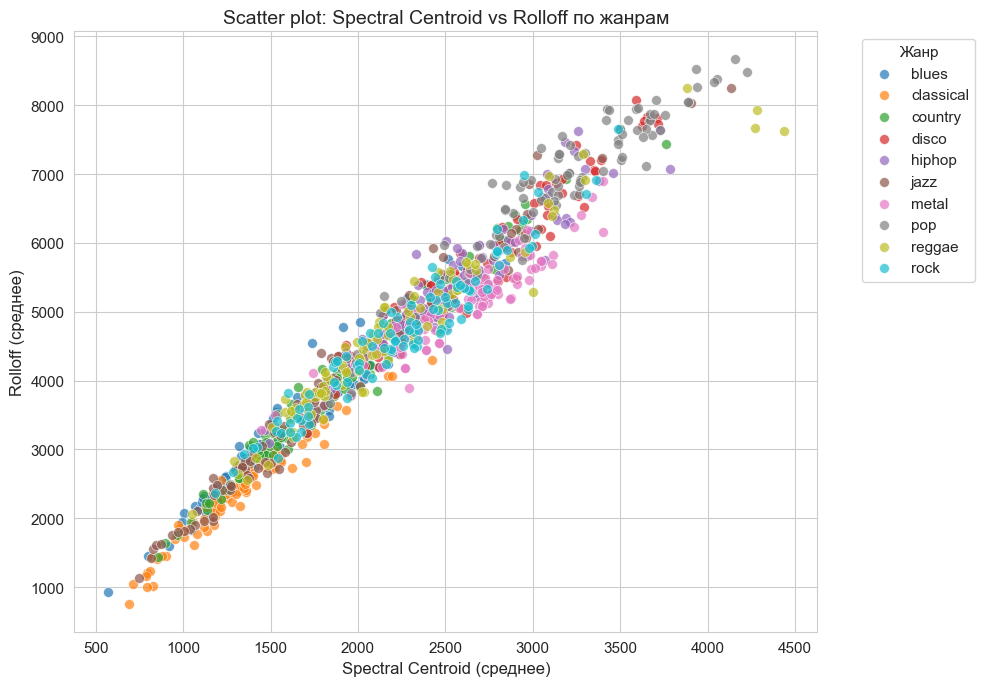

In [176]:
genres = df['label'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))
genre_colors = dict(zip(genres, colors))

fig, ax = plt.subplots(figsize=(10, 7))

for genre in genres:
    subset = df[df['label'] == genre]
    ax.scatter(
        subset['spectral_centroid_mean'],
        subset['rolloff_mean'],
        c=[genre_colors[genre]],
        label=genre,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        s=50
    )

ax.set_xlabel('Spectral Centroid (среднее)', fontsize=12)
ax.set_ylabel('Rolloff (среднее)', fontsize=12)
ax.set_title('Scatter plot: Spectral Centroid vs Rolloff по жанрам', fontsize=14)
ax.legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Интерпретация:** Наблюдается сильная положительная корреляция между spectral centroid и rolloff — чем выше спектральный центроид, тем выше частота среза. Жанры **pop, metal и hiphop** группируются в правой верхней части (высокая «яркость» звука), тогда как **classical и jazz** занимают нижний левый угол (мягкий, тёплый тембр с преобладанием низких и средних частот). **Rock** разбросан по всему диапазону — жанр ранородный по тембру.

### 1.2. Столбчатая диаграмма средних значений признаков по жанрам

Построим сгруппированную столбчатую диаграмму средних значений ключевых аудиопризнаков по жанрам, чтобы увидеть, какие признаки лучше всего различают жанры.

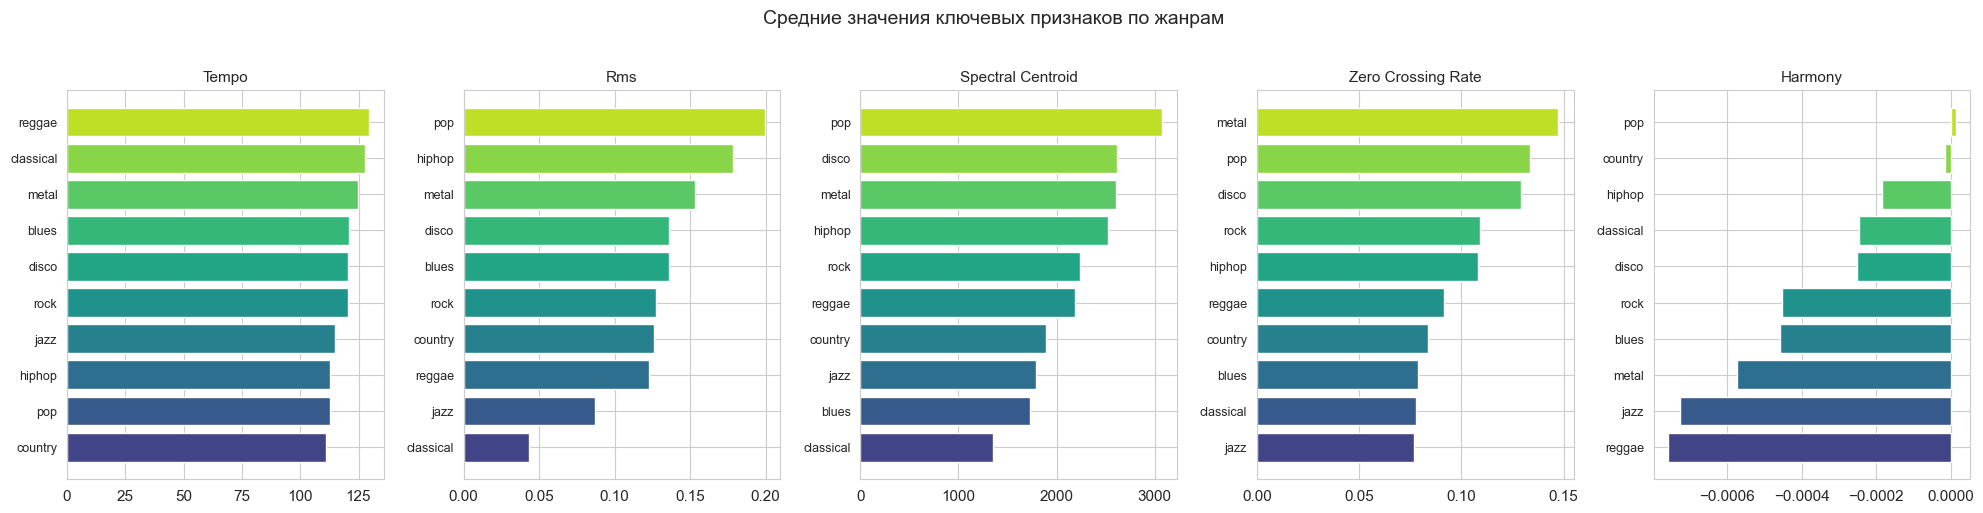

In [177]:
key_features = ['tempo', 'rms_mean', 'spectral_centroid_mean',
                'zero_crossing_rate_mean', 'harmony_mean']

means = df.groupby('label')[key_features].mean()

fig, axes = plt.subplots(1, len(key_features), figsize=(20, 5))

for i, feat in enumerate(key_features):
    sorted_means = means[feat].sort_values(ascending=True)
    bars = axes[i].barh(sorted_means.index, sorted_means.values, color=plt.cm.viridis(
        np.linspace(0.2, 0.9, len(sorted_means))))
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title(), fontsize=11)
    axes[i].tick_params(axis='y', labelsize=9)

fig.suptitle('Средние значения ключевых признаков по жанрам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация:** Каждый признак по-разному разделяет жанры. Например, tempo выше всего у reggue и blues, RMS (громкость) максимальна у pop и hiphop, а harmony более выражена у reggue и jazz.

### Замечание: GTZAN ≠ реальность

**Tempo** в датасете не всегда отражает реальные BPM жанра:
- **Reggae** — в жизни один из самых медленных жанров (60–90 BPM), а в GTZAN он в топе (~130). Причина: librosa **удваивает темп** при сложной off-beat-ритмике
- **Metal** в реальности 120–180+ BPM — должен лидировать, но в датасете средний
- **Hip-hop** в реальности 85–100 BPM, в датасете завышен

**RMS (громкость)** тоже искажён:
- Pop в топе из-за современного **мастеринга с компрессией** ("loudness war"), а не из-за реальной энергии
- Записи частично **нормализованы** — измеряется не абсолютная громкость, а динамический характер

**Причины:**
1. Алгоритмы детекции темпа часто ошибаются на сложных ритмах
2. GTZAN — старый датасет (2002), разное качество записей
3. 30 секунд — случайный фрагмент, не весь трек
4. Нормализация на этапе подготовки искажает амплитуды

**Для ML это не критично** — модель учится на признаках датасета, а не на «истинных» характеристиках жанров. Но для музыковедческой интерпретации картина искажена, особенно по tempo.


### 1.3. Визуализация матрицы признаков (imshow)

Функция `imshow()` позволяет отображать двумерные данные в виде цветовой матрицы. Визуализируем средние значения всех признаков по жанрам — это даёт общую «карту» различий между жанрами.

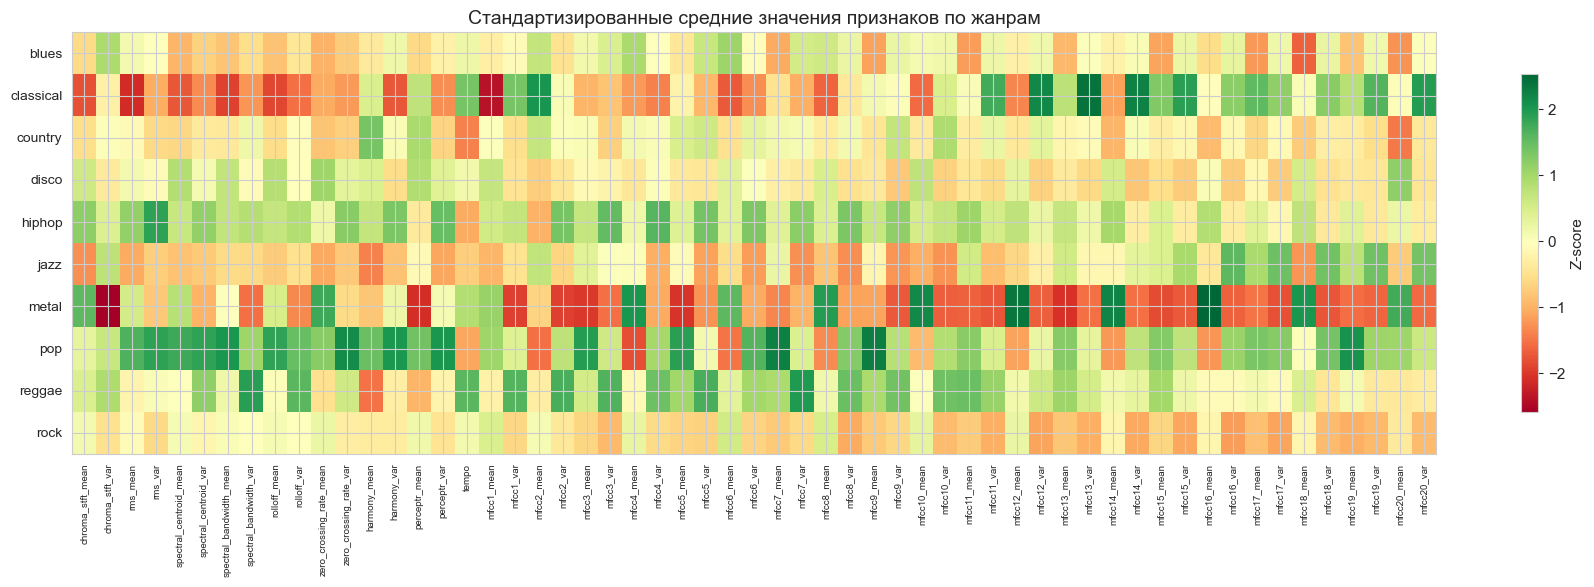

In [178]:
from sklearn.preprocessing import StandardScaler

genre_means = df.groupby('label')[numeric_cols].mean()

# Стандартизируем для сопоставимости масштабов
scaler = StandardScaler()
genre_means_scaled = pd.DataFrame(
    scaler.fit_transform(genre_means),
    index=genre_means.index,
    columns=genre_means.columns
)

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(genre_means_scaled.values, cmap='RdYlGn', aspect='auto')

ax.set_yticks(range(len(genre_means_scaled.index)))
ax.set_yticklabels(genre_means_scaled.index, fontsize=10)
ax.set_xticks(range(len(genre_means_scaled.columns)))
ax.set_xticklabels(genre_means_scaled.columns, rotation=90, fontsize=7)
ax.set_title('Стандартизированные средние значения признаков по жанрам', fontsize=14)

plt.colorbar(im, ax=ax, shrink=0.8, label='Z-score')
plt.tight_layout()
plt.show()

**Интерпретация:** Матрица показывает «портрет» каждого жанра в пространстве признаков. У каждого жанра свой характерный узор зелёных и красных клеток.

- **Classical** ярко выделяется: **минимум** по всем энергетическим и спектральным признакам (`rms`, `spectral_centroid`, `rolloff`, `zero_crossing_rate` — сплошной красный) — тихий, мягкий, низкочастотный звук. В области MFCC — тоже преимущественно **отрицательные** значения (`mfcc1` ≈ −2.4, `mfcc6` ≈ −1.5, `mfcc8` ≈ −1.5, `mfcc10` ≈ −1.4), но одно яркое исключение — **`mfcc2` (+2.1)**, самое высокое среди всех жанров.
- **Pop** — **максимум** по `rms_mean`, `spectral_centroid_mean`, `rolloff_mean`, `spectral_bandwidth_mean` (самый громкий и «плотный» звук, частично из-за современного мастеринга с компрессией).
- **Metal** — **максимум** по `zero_crossing_rate_mean` (шумный, высокочастотный звук); спектральные признаки тоже высокие, но уступают pop.
- **Pop и metal почти зеркально противоположны** в области MFCC 3–10: у pop положительные значения на нечётных номерах (`mfcc3`, `5`, `7`, `9`), у metal — на чётных (`mfcc4`, `6`, `8`, `10`), и наоборот. Такие контрастные «отпечатки» объясняют, почему классификаторы легко различают эти жанры.
- **Reggae** — выделяется высокими значениями `harmony_mean` и `perceptr_mean`, а также нечётных MFCC (`mfcc5`, `mfcc7`, `mfcc9`) — характерный гармонический и тембровый профиль.
- **Hiphop** — похож на pop, но контрасты менее выражены: высокие rms и спектральные, умеренные MFCC.
- **Country, disco, rock, blues, jazz** — более «средние» профили без ярких экстремумов. Именно поэтому эти жанры обычно хуже отделимы друг от друга — модели их чаще путают.

---
## 2. Гистограммы распределений по всем признакам

Гистограмма показывает, сколько наблюдений попадает в каждый интервал значений. Это основной инструмент для оценки формы распределения: нормальное, скошенное, бимодальное и т.д. Наложение кривой KDE (Kernel Density Estimation) позволяет увидеть сглаженную оценку плотности.

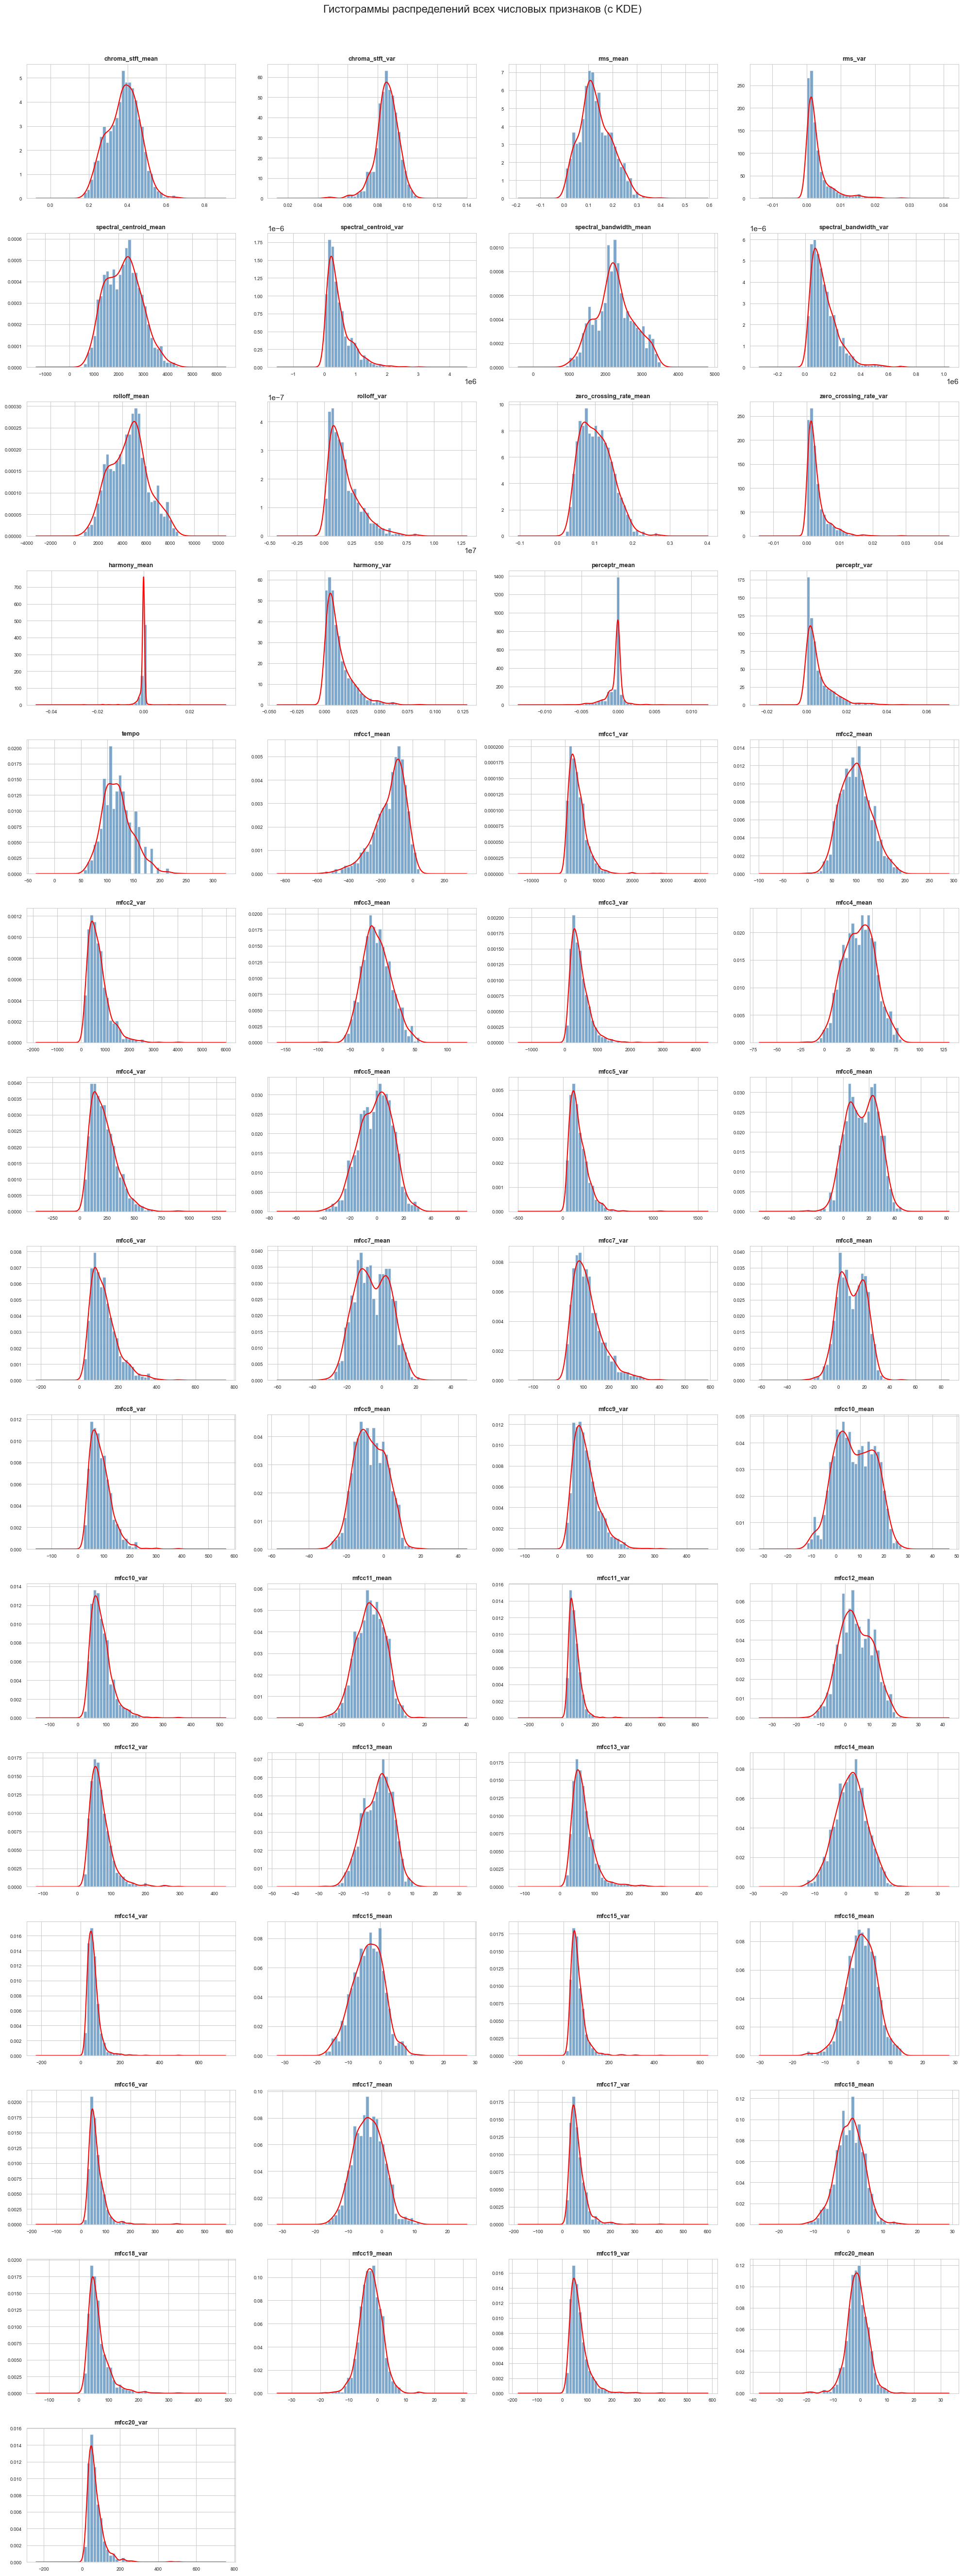

In [179]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white',
            alpha=0.7, density=True)
    df[col].plot.kde(ax=ax, color='red', linewidth=1.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_ylabel('')

# Скрыть пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Гистограммы распределений всех числовых признаков (с KDE)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:** Форма распределения сильно отличается от признака к признаку.

- **tempo** — распределение с «хвостом вправо»: самые частые значения около 100–120 BPM, но есть редкие треки с очень высоким темпом до ~400.
- **harmony_mean** и **perceptr_mean** — **почти все значения плотно сгруппированы вокруг нуля**, а за его пределами только редкие выбросы. На графике это выглядит как очень узкий острый пик — признак несёт мало информации в «центре», но отдельные выбросы могут быть значимы.
- **Спектральные признаки** (`spectral_centroid_mean`, `rolloff_mean`, `zero_crossing_rate_mean`) — форма близка к **нормальному** (колоколообразному) распределению, с небольшим сдвигом вправо.
- У части MFCC (`mfcc7_mean`, `mfcc8_mean`, `mfcc9_mean`, `mfcc10_mean`) видно **два пика** вместо одного (**бимодальное** распределение). Два пика почти всегда означают, что в выборке есть две разные подгруппы, у каждой свой «центр» значений. **Гипотеза:** эти подгруппы — разные жанры. Проверим ниже.
- Признаки дисперсии (`*_var`) почти все сильно скошены вправо (длинный хвост больших значений). Перед обучением моделей их имеет смысл масштабировать или брать логарифм.

### 2.1. Проверка гипотезы: бимодальность MFCC = различия между жанрами

**Идея проверки.** Если два пика на общей гистограмме действительно появляются из-за смешивания жанров, то стоит посмотреть на распределение **отдельно для каждого жанра**. Ожидаем увидеть, что у каждого жанра всего **один пик** (одно типичное значение), а сами пики **расположены в разных местах оси**. Сумма таких одногорбых кривых при взгляде «в общем» даёт два горба.

Нарисуем для каждого из четырёх бимодальных MFCC: общую гистограмму (серый фон) + KDE-кривую плотности для каждого жанра (цветные линии).

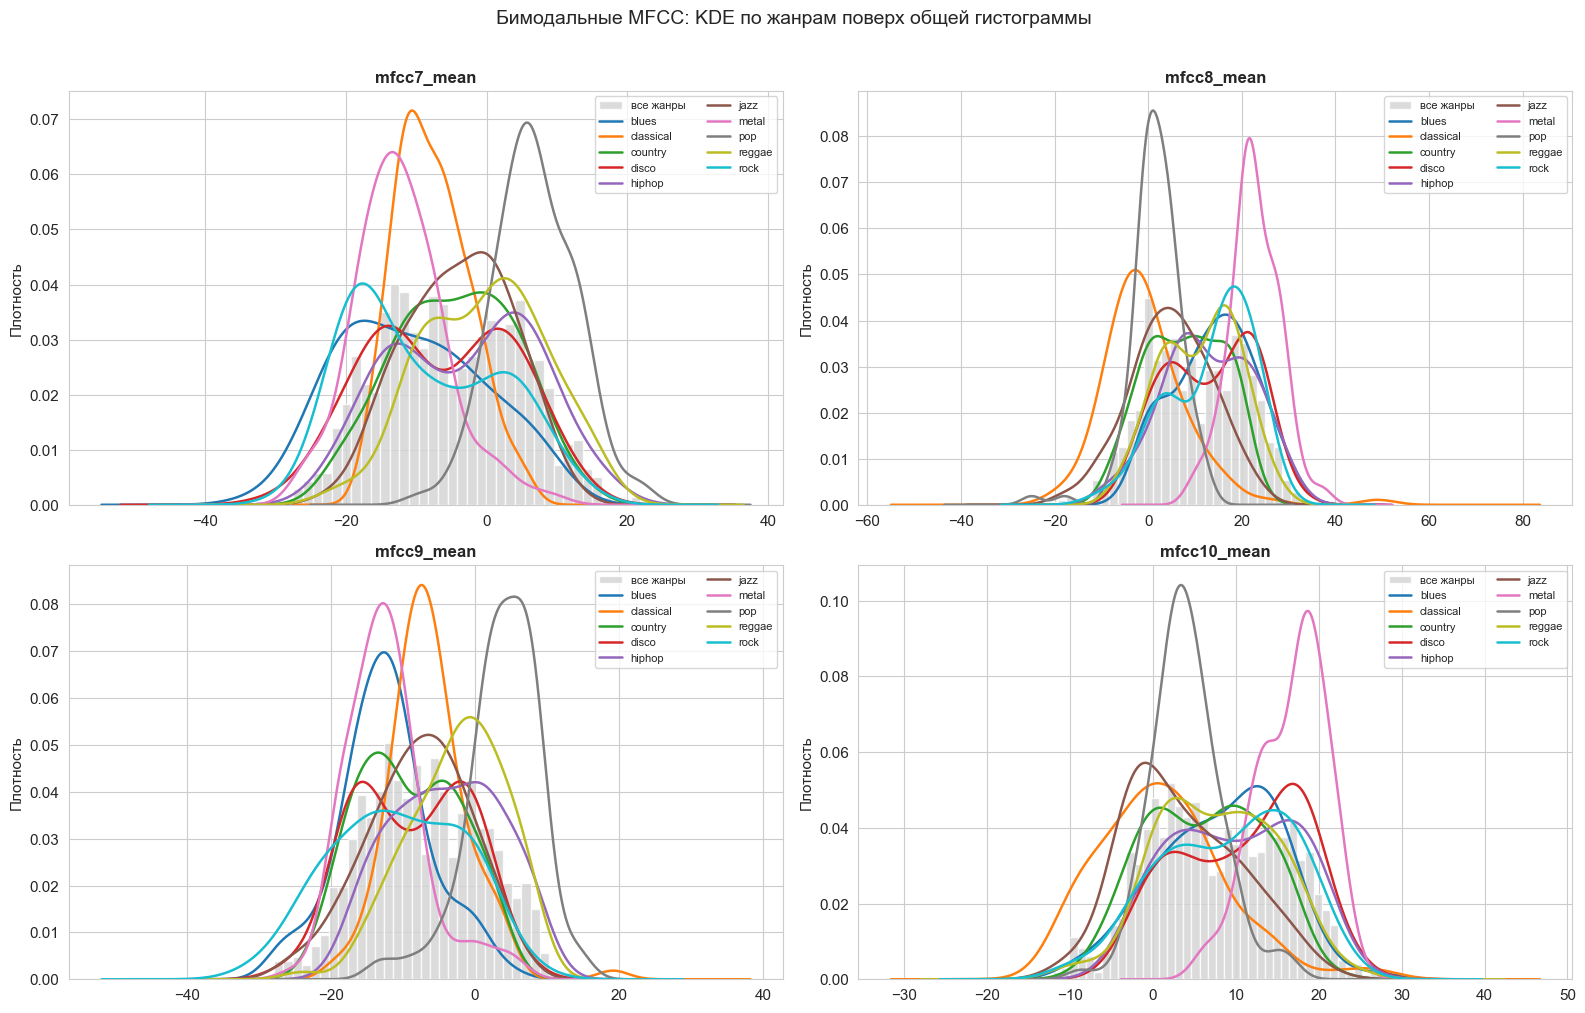

In [180]:
bimodal_mfcc = ['mfcc7_mean', 'mfcc8_mean', 'mfcc9_mean', 'mfcc10_mean']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(bimodal_mfcc):
    ax = axes[i]
    # Серый фон — общая гистограмма (как на исходном графике)
    ax.hist(df[feat], bins=40, color='lightgray', edgecolor='white',
            density=True, alpha=0.8, label='все жанры')
    # Поверх — KDE по каждому жанру отдельно
    for genre in sorted(genres):
        subset = df.loc[df['label'] == genre, feat]
        subset.plot.kde(ax=ax, label=genre, color=genre_colors[genre], linewidth=1.8)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8, ncol=2, loc='upper right')

fig.suptitle('Бимодальные MFCC: KDE по жанрам поверх общей гистограммы',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Дополнительно — посчитаем медианные значения каждого MFCC по жанрам, чтобы явно увидеть, какие жанры «сидят» в левом пике, а какие — в правом.

In [181]:
medians = df.groupby('label')[bimodal_mfcc].median().round(2)
# Сортируем жанры по mfcc7_mean, чтобы было видно упорядочение
medians_sorted = medians.sort_values('mfcc7_mean')
medians_sorted.style.background_gradient(cmap='RdYlGn_r', axis=0)

,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean
label,,,,
metal,-12.800000,22.110000,-12.750000,17.790000
rock,-11.240000,15.350000,-10.830000,10.160000
blues,-11.210000,14.800000,-12.270000,8.600000
classical,-8.180000,-1.560000,-7.090000,0.370000
disco,-7.450000,13.920000,-8.890000,12.280000
country,-4.100000,8.520000,-10.310000,6.800000
jazz,-3.720000,5.230000,-7.700000,2.300000
hiphop,-1.760000,12.460000,-4.020000,10.190000
reggae,0.560000,12.150000,-1.640000,8.120000


**Вывод проверки:**

- **Основная гипотеза подтвердилась.** У большинства жанров распределение на этих MFCC **одногорбое** (один пик), а два горба на общей гистограмме возникают из-за того, что пики разных жанров стоят в разных местах оси. Итоговая картинка — это просто сумма 10 одногорбых кривых.

- **Но есть исключения.** Формальная проверка пиков обнаружила **внутрижанровую бимодальность** у нескольких жанров:
  - **disco** — чемпион: два пика на `mfcc7_mean` (≈−14 и +2), `mfcc8_mean` (≈+5 и +21) и `mfcc9_mean` (≈−16 и −2);
  - **hiphop** — два пика на `mfcc7_mean` (≈−13 и +4);
  - **country** — два пика на `mfcc10_mean` (≈+1 и +10).

  Это говорит о том, что **внутри этих жанров есть подстили с разным тембром** (например, диско 70-х vs современные электронные варианты, хип-хоп старой школы vs современный). Метки GTZAN, судя по всему, не полностью однородны.

- **Pop и metal ведут себя «зеркально» в зависимости от MFCC:**
  - на `mfcc7_mean` и `mfcc9_mean`: **pop справа** (+6.5, +4.3), а **metal слева** (−12.8, −12.8);
  - на `mfcc8_mean` и `mfcc10_mean` — **наоборот**: metal справа (+22.1, +17.8), pop слева (+1.5, +3.5).

  Такое устойчивое противопоставление даёт классификатору очень надёжный сигнал для различения этих жанров.

- **Classical** на всех четырёх MFCC стоит **на краю или в стороне** от основной массы жанров: на `mfcc8` и `mfcc10` — самый левый (−1.6 и +0.4), на `mfcc7` и `mfcc9` — в левой трети. Отсюда его хорошая отделимость.

- **Rock** кажется двугорбым глазами, но формально у него **один пик с асимметричным плечом**. Это похоже на бимодальность, но по строгому критерию второй «горб» не значим.

- **Практический вывод:** MFCC 7–10 — сильные признаки для классификации, «облака» разных жанров на них хорошо разделены. Но наличие внутренней бимодальности у disco/hiphop/country — повод быть осторожным с методами, предполагающими одно типичное значение на класс (GaussianNB, LDA). Для этих жанров лучше работают модели, допускающие сложную форму распределения: деревья, случайный лес, KNN.

---
## 3. Ящик с усами (Boxplot) для выявления выбросов

**Box plot** (ящик с усами) — один из ключевых инструментов описательной статистики. Он одновременно показывает медиану, межквартильный размах (IQR), «усы» (1.5*IQR от границ ящика) и выбросы (точки за пределами усов). Построим boxplot для ключевых признаков в разбивке по жанрам.

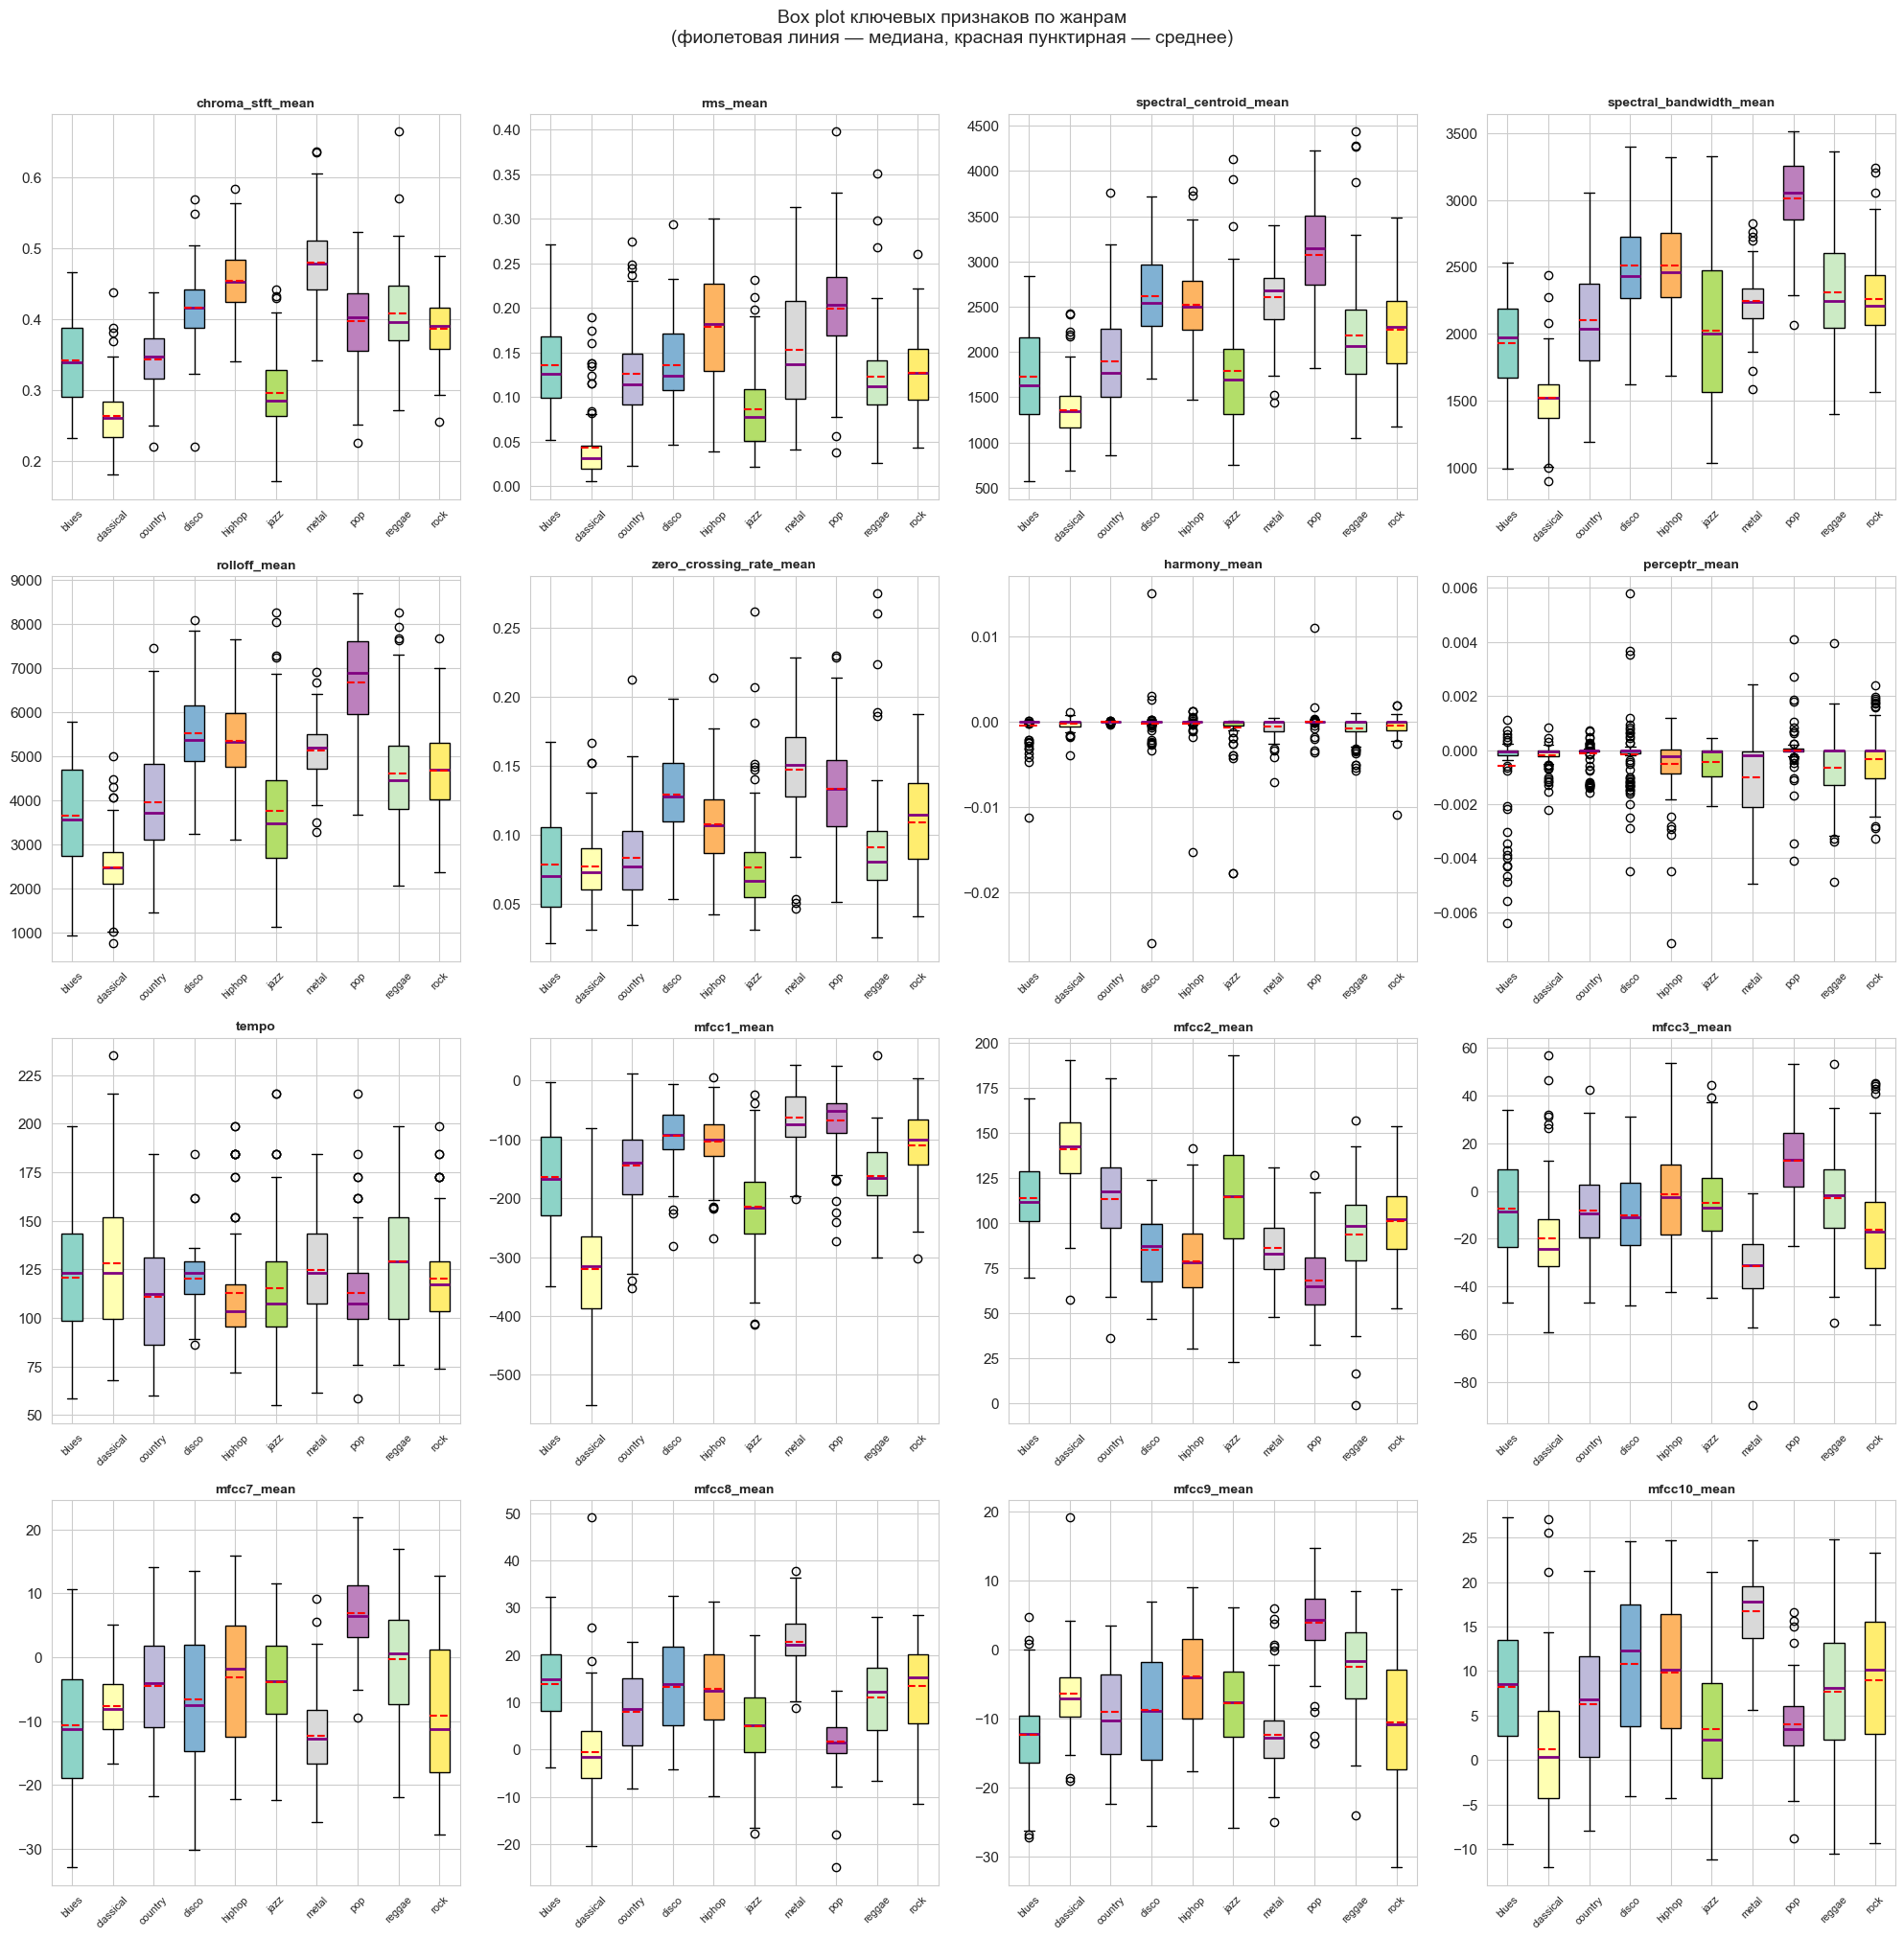

In [182]:
boxplot_features = [
    'chroma_stft_mean', 'rms_mean', 'spectral_centroid_mean',
    'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean',
    'harmony_mean', 'perceptr_mean', 'tempo',
    'mfcc1_mean', 'mfcc2_mean', 'mfcc3_mean',
    'mfcc7_mean', 'mfcc8_mean', 'mfcc9_mean', 'mfcc10_mean'
]

n_cols = 4
n_rows = (len(boxplot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, feat in enumerate(boxplot_features):
    ax = axes[i]
    data_by_genre = [df[df['label'] == g][feat].values for g in sorted(genres)]
    bp = ax.boxplot(data_by_genre, labels=sorted(genres), patch_artist=True,
                    showmeans=True, meanline=True,
                    medianprops={'linewidth': 2, 'color': 'purple'},
                    meanprops={'linewidth': 1.5, 'color': 'red', 'linestyle': '--'})

    palette = plt.cm.Set3(np.linspace(0, 1, len(genres)))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# Скрыть пустые ячейки
for j in range(len(boxplot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Box plot ключевых признаков по жанрам\n'
             '(фиолетовая линия — медиана, красная пунктирная — среднее)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:**

- Почти у всех признаков на графиках много **выбросов** — точек за пределами усов. Для аудиопризнаков это нормально: внутри одного жанра всегда встречаются треки нестандартного звучания.
- **pop** — лидер по громкости и «яркости»: максимальные медианы у `rms_mean` (0.20), `spectral_centroid_mean` (3144) и `rolloff_mean`. **hiphop**, **metal** и **disco** идут следом. Высокие значения у pop частично объясняются современным мастерингом с компрессией (плотный, громкий звук).
- **classical** — минимум почти по всем энергетическим и спектральным признакам (`rms_mean` ≈ 0.03, `spectral_centroid_mean` ≈ 1345): тихий, низкочастотный звук, мало высокочастотных компонент.
- **metal** выделяется высоким `zero_crossing_rate_mean` (шумный, высокочастотный звук) и широким «ящиком» у `rms_mean` (громкость сильно меняется от трека к треку).
- **harmony_mean** и **perceptr_mean** — у всех жанров «ящики» прижаты к нулю, видно много выбросов-точек. Это та же ситуация, что и в разделе 2: основная масса значений у нуля, плюс редкие сильные отклонения.
- `tempo` ведёт себя похоже во всех жанрах — медианы около 120 BPM, ящики сильно перекрываются. Сам по себе темп **слабо разделяет** жанры в этом датасете.
- **MFCC 7–10** (нижний ряд) — ящики разных жанров заметно **сдвинуты друг относительно друга по вертикали**. Направление сдвига меняется от коэффициента к коэффициенту: на `mfcc7_mean` metal внизу (медиана −12.8), pop наверху (+6.5); на `mfcc10_mean` наоборот — metal наверху (+17.8), classical и jazz внизу (+0.4 и +2.3). Именно такое разнесение медиан на общей гистограмме из раздела 2 и создаёт **два пика** — а значит, эти MFCC сильно помогают отличать жанры друг от друга.

---
## 4. Тепловая карта корреляций (Seaborn)

Seaborn — высокоуровневая надстройка над Matplotlib, которая упрощает построение статистических графиков. Тепловая карта корреляционной матрицы позволяет одним взглядом оценить, какие признаки сильно связаны друг с другом, а какие — нет.

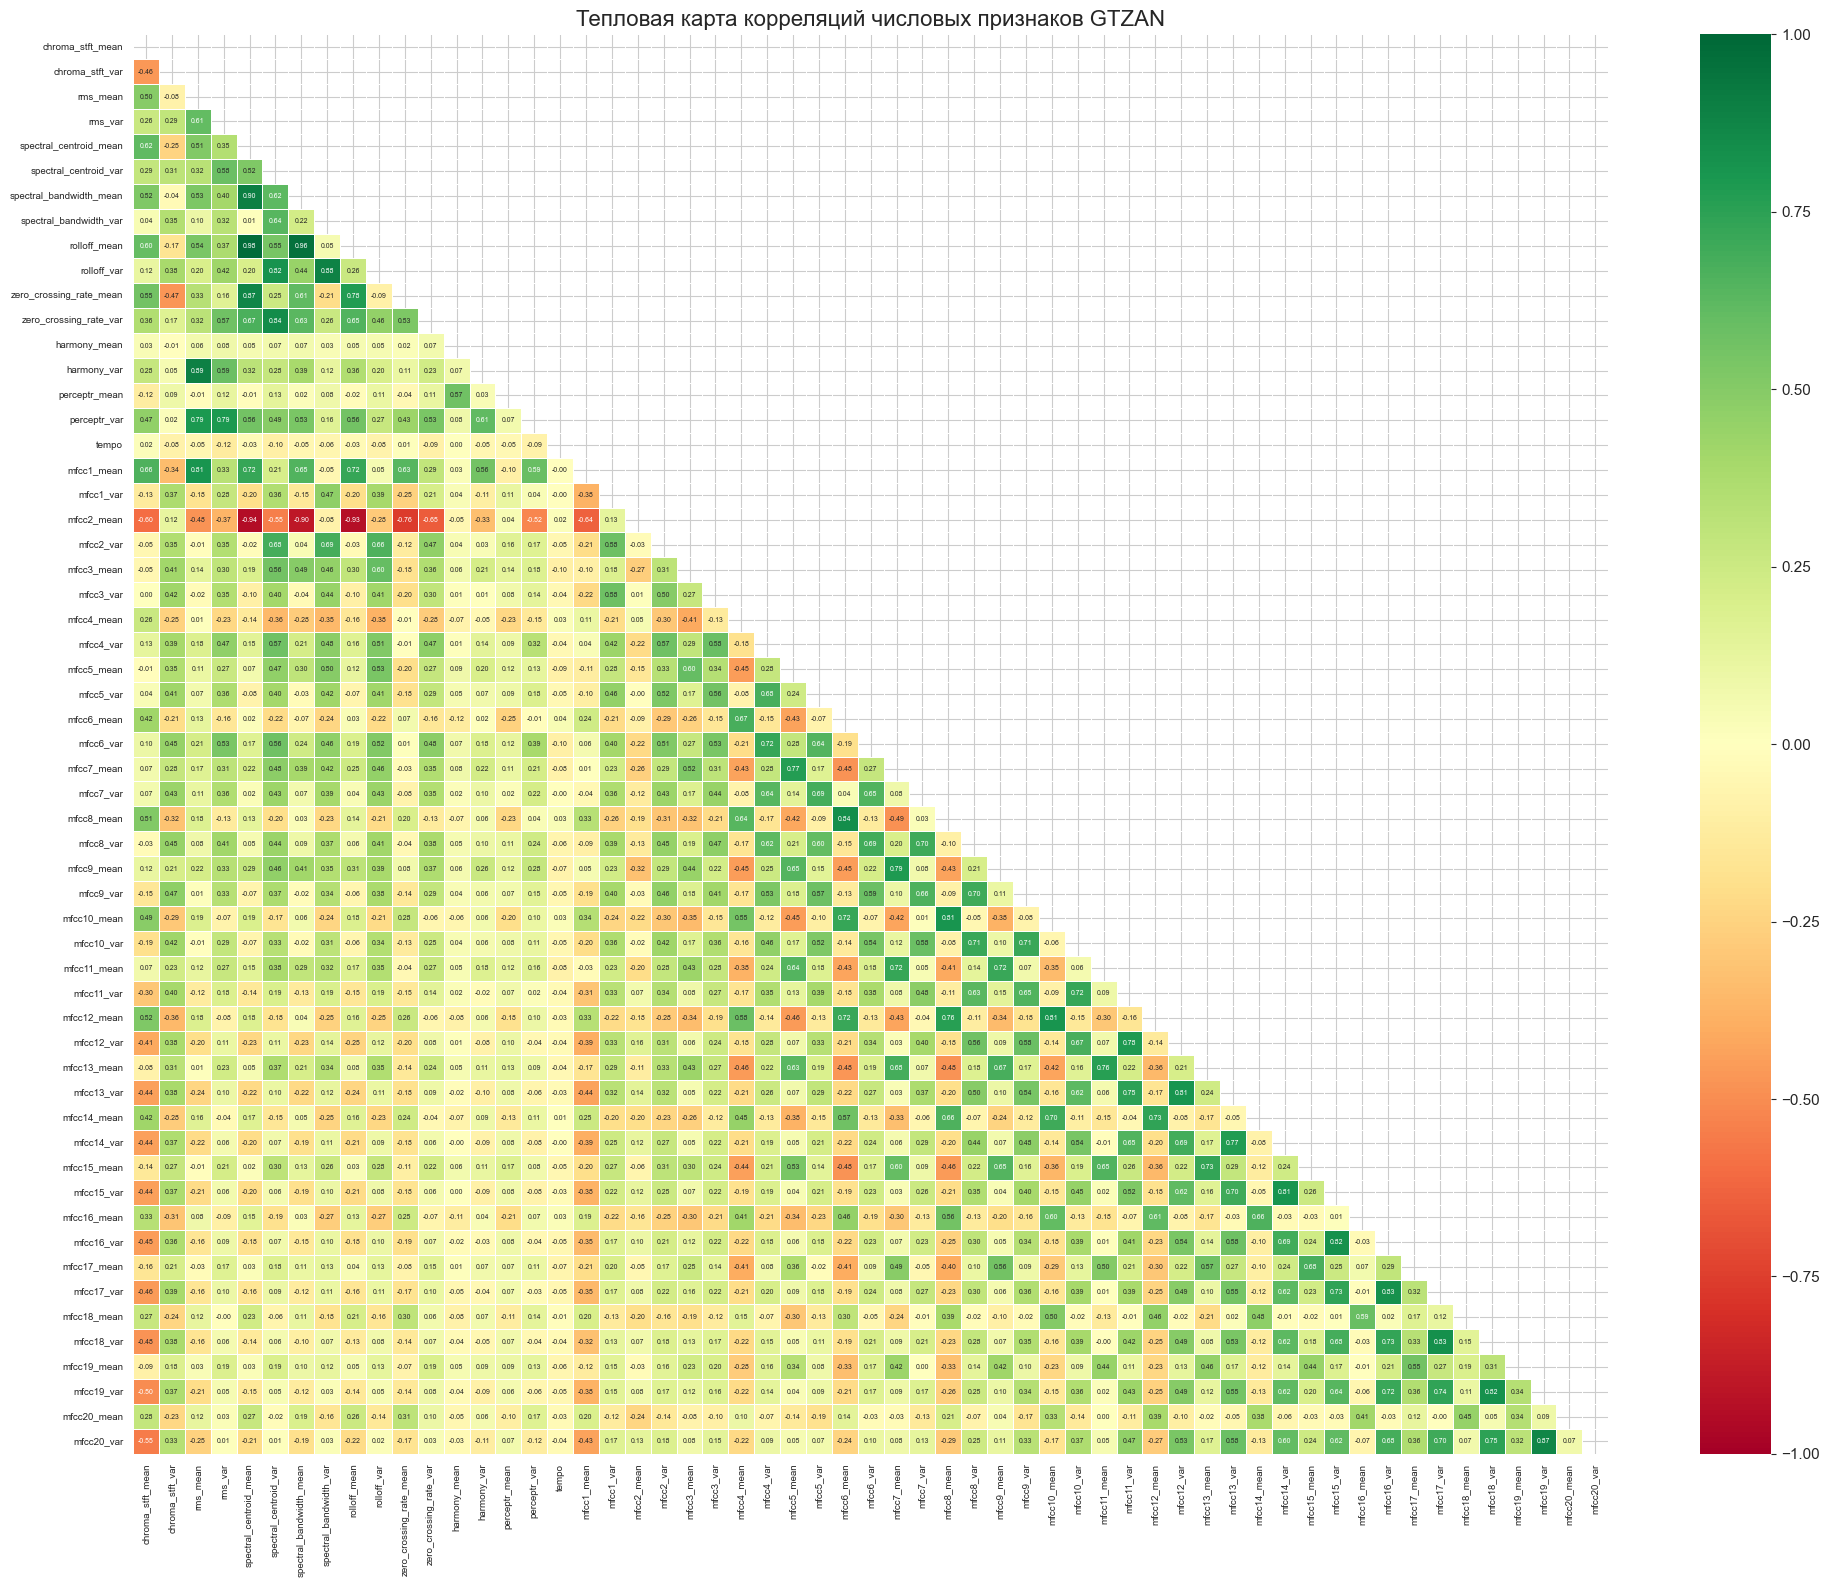

In [183]:
corr_matrix = df[numeric_cols].corr()

# Показываем только нижний треугольник, чтобы избежать дублирования
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 5},
    ax=ax,
    vmin=-1,
    vmax=1
)
ax.set_title('Тепловая карта корреляций числовых признаков GTZAN', fontsize=16)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

### Выводы по корреляционной матрице

**1. «Яркостный» кластер** — четыре спектральных признака измеряют почти одно и то же (|r| > 0.85):
- `spectral_centroid_mean` ↔ `rolloff_mean` = **0.98** (практически дубликат);
- `spectral_bandwidth_mean` ↔ `rolloff_mean` = 0.96;
- `spectral_centroid_mean` ↔ `spectral_bandwidth_mean` = 0.90;
- `spectral_centroid_mean` ↔ `zero_crossing_rate_mean` = 0.87.

Все они описывают «яркость» тембра. Для линейных моделей это **мультиколлинеарность** — можно оставить один из четырёх.

**2. MFCC2 — «анти-яркость».** Красная полоса в строке `mfcc2_mean` показывает, что этот коэффициент **сильно отрицательно** связан со спектральными признаками:
- `mfcc2_mean` vs `spectral_centroid_mean` = **−0.94**;
- `mfcc2_mean` vs `rolloff_mean` = −0.93;
- `mfcc2_mean` vs `spectral_bandwidth_mean` = −0.90.

Фактически `mfcc2` — это инвертированный индикатор яркости. Если в модели уже есть `spectral_centroid`, `mfcc2` добавит мало новой информации.

**3. Неочевидная связка `rms` ↔ гармония/перкуссия:**
- `rms_mean` ↔ `harmony_var` = **0.89** (в топ-10);
- `rms_mean` ↔ `perceptr_var` = 0.79;
- `rms_mean` ↔ `mfcc1_mean` = 0.81 (mfcc1 — логарифм общей энергии, логично).

У громких треков больше **динамики** в гармонической и перкуссионной составляющих (librosa разделяет сигнал на эти две части).

**4. MFCC между собой — не «слабо», как может показаться.** Внутри MFCC есть умеренно-сильные связи:
- `mfcc6_mean` ↔ `mfcc8_mean` = 0.84;
- `mfcc8_mean` ↔ `mfcc10_mean` = 0.81;
- `mfcc7_mean` ↔ `mfcc9_mean` = 0.79;
- `mfcc5_mean` ↔ `mfcc7_mean` = 0.77.

**Закономерность:** MFCC через один (чётный-чётный, нечётный-нечётный) коррелируют умеренно сильно. Именно этим объясняется «зеркальность» pop и metal из раздела 1.3 — они противоположны отдельно на чётных и отдельно на нечётных MFCC.

**5. `harmony_mean` ↔ `perceptr_mean` = +0.57** — **положительная** умеренная корреляция (а не отрицательная, как можно было ожидать из «противоположных» названий).

**6. Tempo — независимый признак.** Строка `tempo` на карте почти полностью жёлтая (корреляции ≈ 0 со всеми остальными признаками). Значит `tempo` несёт **уникальную** информацию, ничего не дублирует, и при отборе признаков его удалять не стоит.

### Практический вывод для отбора признаков

Кандидаты на удаление (для снижения мультиколлинеарности в линейных моделях):
- **`rolloff_mean`** (дубликат `spectral_centroid_mean`, r = 0.98);
- **`mfcc2_mean`** (инверсия `spectral_centroid_mean`, r = −0.94);
- один из `spectral_bandwidth_mean` / `spectral_centroid_mean`.

Это снизит размерность с 57 до ~53–54 практически без потери информации. Для моделей на основе деревьев (Random Forest, XGBoost) мультиколлинеарность не критична — там можно оставлять все признаки.

### Топ-10 пар признаков с наибольшей корреляцией

In [184]:
# Извлекаем уникальные пары с наибольшей корреляцией
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Признак 1', 'Признак 2', 'Корреляция']
corr_pairs['|Корреляция|'] = corr_pairs['Корреляция'].abs()
corr_pairs.sort_values('|Корреляция|', ascending=False).head(10).drop(columns='|Корреляция|')

,Признак 1,Признак 2,Корреляция
221,spectral_centroid_mean,rolloff_mean,0.979637
322,spectral_bandwidth_mean,rolloff_mean,0.956189
232,spectral_centroid_mean,mfcc2_mean,-0.940180
430,rolloff_mean,mfcc2_mean,-0.934302
219,spectral_centroid_mean,spectral_bandwidth_mean,0.904435
333,spectral_bandwidth_mean,mfcc2_mean,-0.896652
121,rms_mean,harmony_var,0.893898
372,spectral_bandwidth_var,rolloff_var,0.884877
223,spectral_centroid_mean,zero_crossing_rate_mean,0.874749
1594,mfcc19_var,mfcc20_var,0.868718


---
## 5. Продвинутые визуализации Seaborn

### 5.1. Violin plot — распределения по жанрам

Violin plot сочетает информацию box plot и KDE-оценки плотности. Внутри «скрипки» показана медиана и квартили, а форма отражает плотность распределения на каждом уровне значения.

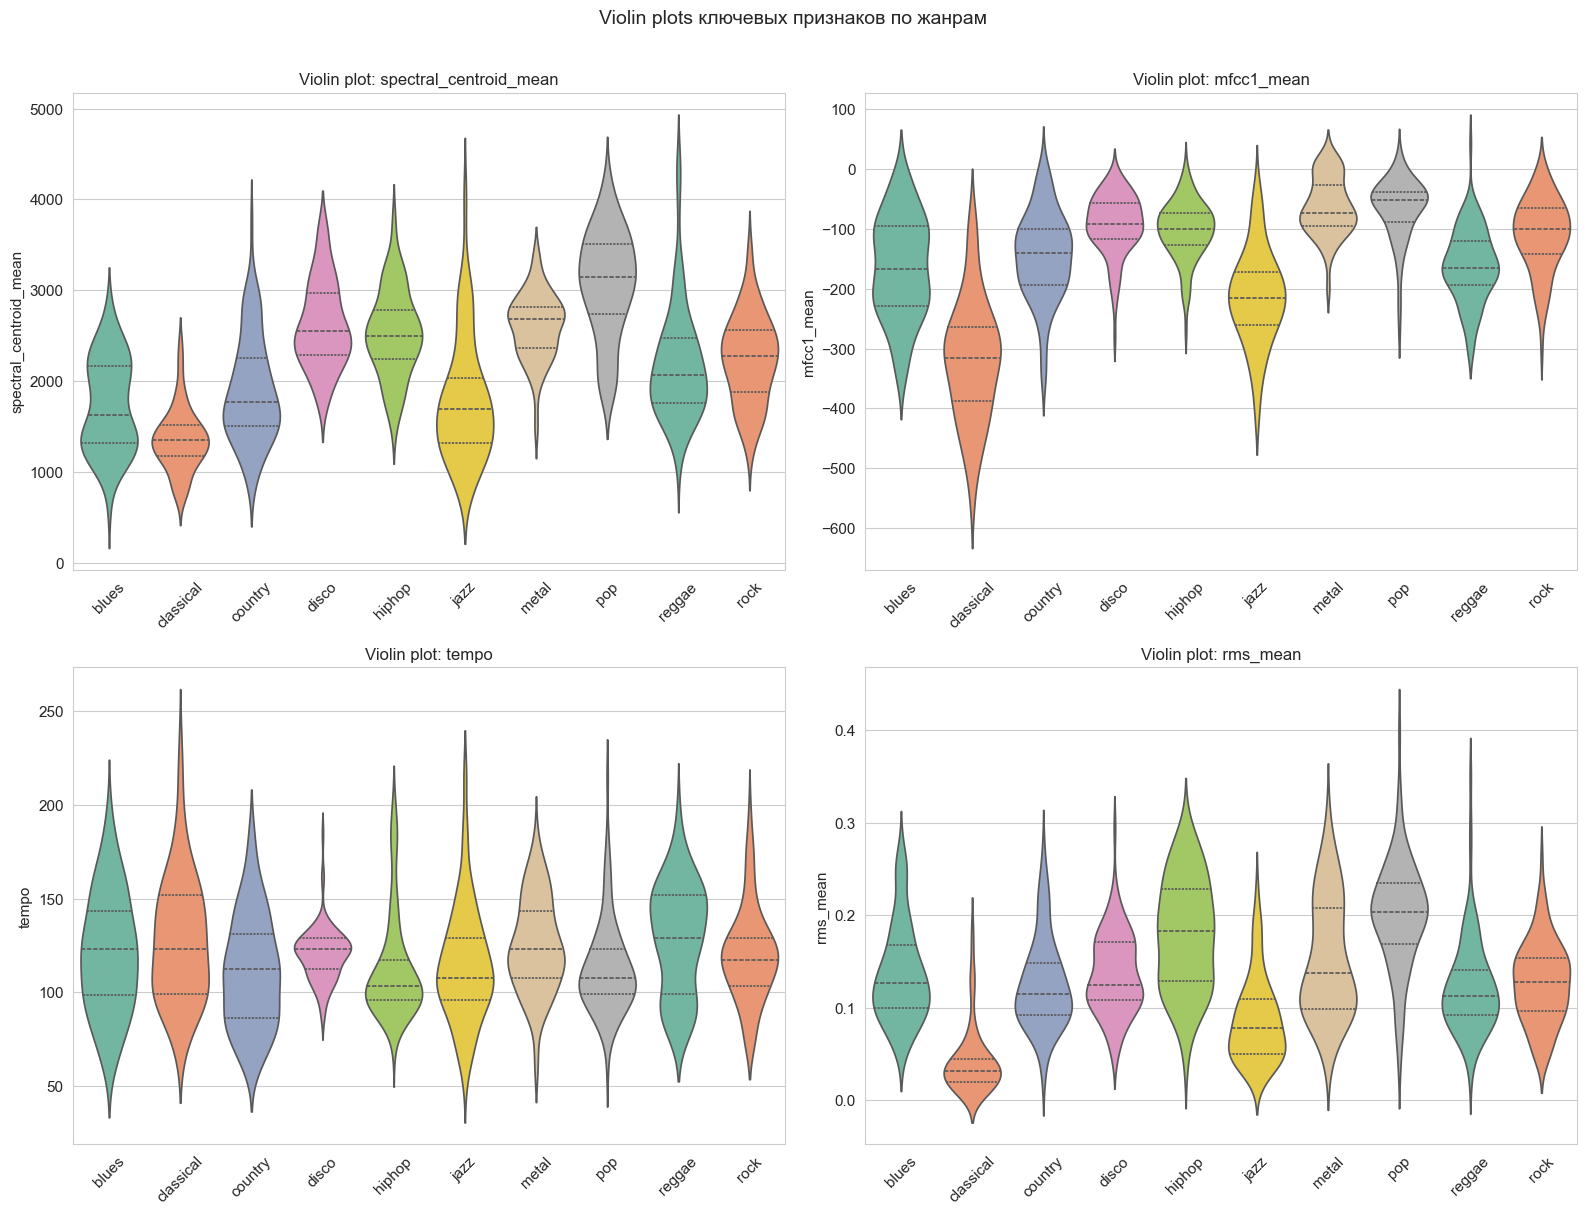

In [185]:
violin_features = ['spectral_centroid_mean', 'mfcc1_mean', 'tempo', 'rms_mean']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(violin_features):
    sns.violinplot(
        data=df, x='label', y=feat,
        palette='Set2', inner='quartile', ax=axes[i]
    )
    axes[i].set_title(f'Violin plot: {feat}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('Violin plots ключевых признаков по жанрам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Интерпретация:**

- **`spectral_centroid_mean`** — самое **низкое и компактное** распределение у **classical** (медиана ~1345), самое **высокое и компактное** — у **pop** (~3144). **metal** и **disco/hiphop** держатся в верхней части (~2500–2700), но менее компактно. **reggae** и **jazz** растянуты очень широко — внутри этих жанров много треков с разной яркостью звука.
- **`mfcc1_mean`** — у всех жанров значения преимущественно **отрицательные**, разделение идёт по **величине отрицательности**:
  - самые «глубокие» отрицательные: **classical** (−315) и **jazz** (−216) — очень тихий и мягкий звук;
  - ближе всего к нулю: **pop** (−53) и **metal** (−74) — громкий, плотный звук;
  - **blues/reggae** (−168/−166), **country** (−140), **rock/hiphop/disco** (−101/−101/−92) — в середине.

  Напомним, `mfcc1` пропорционален логарифму общей энергии — поэтому признак фактически описывает громкость, и шкала тесно связана с `rms_mean`.
- **`tempo`** — все жанры имеют медианы около 120 BPM, «скрипки» сильно перекрываются и растянуты одинаково широко. **Сам по себе темп плохо разделяет жанры** в этом датасете (подтверждает наблюдение из boxplot).
- **`rms_mean`** — повторяет картину из раздела 3: **pop** (0.20) и **hiphop** (0.18) в топе по громкости, **classical** внизу (0.03), широкий разброс у **metal** (скрипка вытянута вертикально — большая дисперсия громкости от трека к треку).

### 5.2. Pair plot — парные зависимости ключевых признаков

Pairplot строит scatter plot для каждой пары признаков и гистограмму для каждого признака на диагонали. Это позволяет одновременно оценить распределения и взаимозависимости.

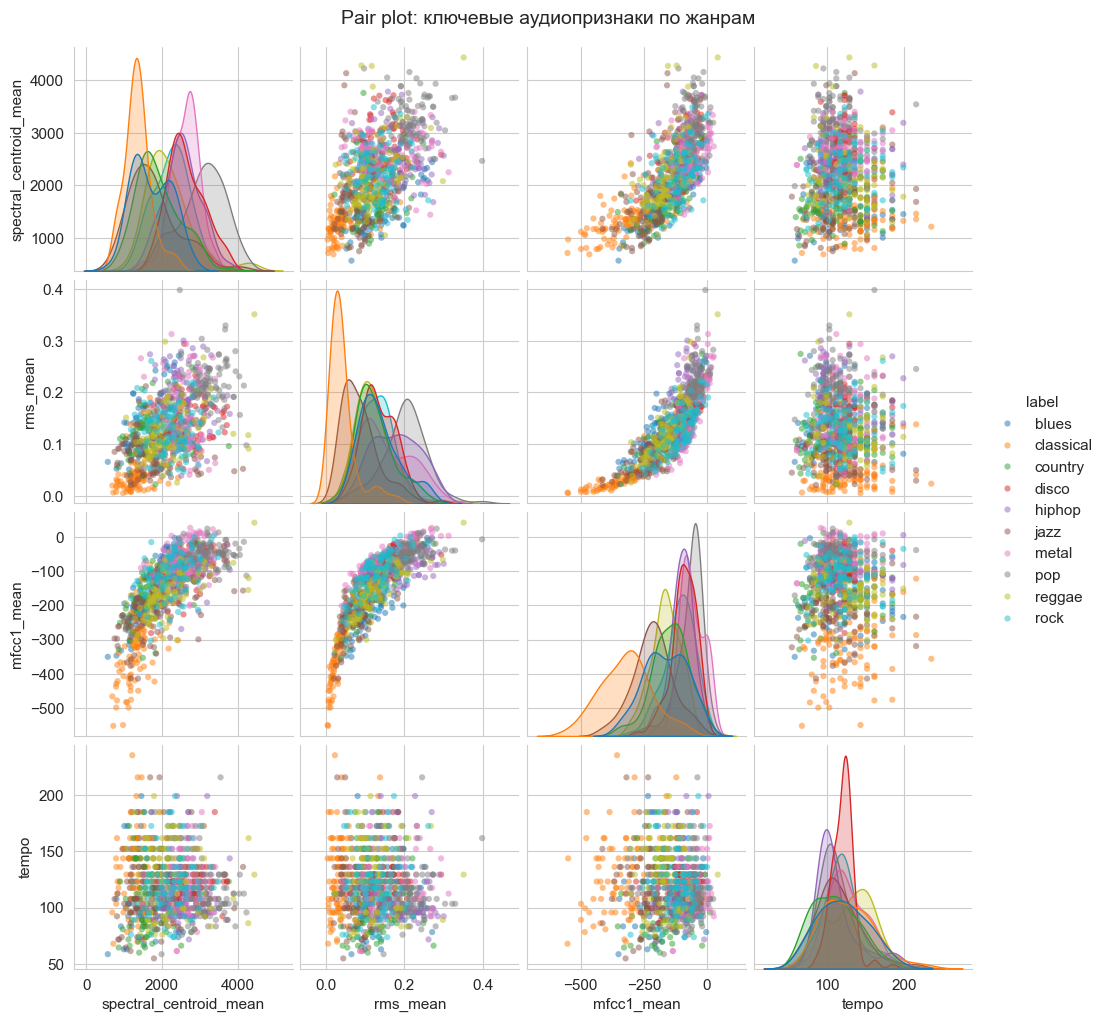

In [186]:
pair_features = ['spectral_centroid_mean', 'rms_mean', 'mfcc1_mean', 'tempo', 'label']

g = sns.pairplot(
    df[pair_features],
    hue='label',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'none'},
    height=2.5
)
g.figure.suptitle('Pair plot: ключевые аудиопризнаки по жанрам', y=1.02, fontsize=14)
plt.show()

**Интерпретация:**

- **`rms_mean` и `mfcc1_mean` — это почти одно и то же.** Scatter показывает чёткую изогнутую кривую (логарифм): когда громкость растёт, значение mfcc1 тоже растёт, но всё медленнее и медленнее, упираясь в ноль. Это не случайность — **mfcc1 по определению — это логарифм общей энергии сигнала**, а `rms` — и есть эта энергия. Корреляция между ними 0.81. Для модели оба признака фактически избыточны: если один уже есть, второй добавляет мало новой информации.

- **Громче → ярче, но с оговоркой.** `rms_mean` × `spectral_centroid_mean` — положительная связь, но форма у облака «расширяющаяся». У тихих треков (classical) обе величины маленькие и плотно сбиты в левом нижнем углу. У громких — **разброс по яркости резко увеличивается**: громкие треки могут быть какими угодно по тембру. Это стоит учитывать: там, где данные «веером расходятся», линейная регрессия и похожие модели работают хуже.

- **Tempo — не совсем непрерывный признак.** На всех scatter с осью tempo видны **горизонтальные полоски** — данные сгущаются на конкретных значениях (123, 129, 117, 108, 99 BPM…), а не размазаны непрерывно. Самое частое — 123 BPM, на нём сидит 94 трека из 1000. Это особенность алгоритма `librosa.beat.tempo`: он предпочитает определять темп в стандартных точках. Для ML-модели tempo ведёт себя скорее как категориальный признак с 10–20 популярными значениями.

- **Что говорят распределения на диагонали (KDE):**
  - **classical** на всех трёх осях (centroid, rms, mfcc1) стоит **отдельно** от остальных жанров — его проще всего узнать;
  - у **pop** самый узкий пик на `rms_mean` — современный мастеринг (компрессия, «loudness war») делает громкость у pop-треков очень однообразной;
  - у **жанров-«середняков»** (blues, country, rock) распределения сильно перекрываются — их труднее различать.

- **Экстремальные точки сверху справа.** В верхней части scatter-графиков с rms и centroid видны **два подозрительных трека**:
  - **`pop.00062.wav`** — самый громкий в датасете (rms = 0.398, centroid ≈ 2468);
  - **`reggae.00086.wav`** — с аномально высокой «яркостью» для reggae (rms = 0.351, centroid = 4435).

  Оба кандидаты на ручную проверку при очистке данных — возможно, нетипичные треки, ошибки маркировки или артефакты записи.

- **Вывод.** Комбинация `spectral_centroid + rms + mfcc1` хорошо отделяет «полярные» жанры (classical ↔ pop/metal). Но для разделения соседних «средних» жанров (blues, country, rock, disco) этих трёх признаков мало — нужны MFCC 7–10 из раздела 2. Сам по себе `tempo` — слабый разделитель: медианы всех жанров сконцентрированы около 120 BPM, классификатор по нему один мало что вытянет.

---
## 6. Интерактивные визуализации с Plotly

Plotly позволяет создавать интерактивные графики с hover-подсказками, масштабированием и выделением. Это особенно полезно при работе с многомерными данными.

### 6.1. Интерактивный scatter plot

In [187]:
fig = px.scatter(
    df, x='tempo', y='spectral_centroid_mean',
    color='label',
    hover_data=['rms_mean', 'mfcc1_mean', 'filename'],
    title='Интерактивный Scatter: Tempo vs Spectral Centroid',
    labels={
        'tempo': 'Темп (BPM)',
        'spectral_centroid_mean': 'Spectral Centroid (среднее)',
        'label': 'Жанр'
    },
    opacity=0.7
)
fig.update_layout(width=900, height=600)
fig.show()

### 6.2. Распределение треков по громкости внутри жанров (stacked bar)

Обычная диаграмма «количество треков по жанрам» в GTZAN ничего не показывает — датасет сбалансирован, у каждого жанра ровно 999 сегментов. Построим более информативный вариант: разобьём все треки на три категории по громкости (`rms_mean`) — **тихие / средние / громкие** — и посмотрим, как они распределяются внутри каждого жанра. Жанры сортируем по доле «громких» треков сверху вниз — сразу видно, где каких больше.

In [188]:
# Разбиваем все треки на три категории по громкости (rms_mean):
# "тихие" — нижняя треть, "средние" — средняя треть, "громкие" — верхняя треть
q_low, q_high = df['rms_mean'].quantile([1/3, 2/3])
df_cat = df.assign(
    rms_category=pd.cut(
        df['rms_mean'],
        bins=[-np.inf, q_low, q_high, np.inf],
        labels=['тихие', 'средние', 'громкие']
    )
)

# Считаем количество треков каждой категории по жанрам
counts = (
    df_cat.groupby(['label', 'rms_category'])
    .size()
    .reset_index(name='Количество')
)

# Сортируем жанры по доле "громких" треков — сверху будут самые громкие жанры
loud_share = (
    counts[counts['rms_category'] == 'громкие']
    .set_index('label')['Количество']
    .sort_values()
)
counts['label'] = pd.Categorical(counts['label'], categories=loud_share.index, ordered=True)
counts = counts.sort_values('label')

fig = px.bar(
    counts,
    x='Количество', y='label', color='rms_category',
    orientation='h',
    category_orders={'rms_category': ['тихие', 'средние', 'громкие']},
    color_discrete_map={'тихие': 'blue', 'средние': 'yellow', 'громкие': 'red'},
    title='Распределение треков по громкости внутри жанров<br>'
          '<sub>жанры отсортированы по доле "громких" треков</sub>',
    labels={'label': 'Жанр', 'rms_category': 'Громкость'},
)
fig.update_layout(width=900, height=500, barmode='stack', legend_title='Громкость')
fig.show()

### 6.3. Интерактивный Box plot

In [189]:
fig = px.box(
    df, x='label', y='spectral_centroid_mean',
    color='label',
    title='Box plot: Spectral Centroid Mean по жанрам (Plotly)',
    labels={'label': 'Жанр', 'spectral_centroid_mean': 'Spectral Centroid (среднее)'},
    points='outliers'
)
fig.update_layout(width=900, height=500, showlegend=False)
fig.show()

### 6.4. Интерактивная гистограмма

In [190]:
fig = px.histogram(
    df, x='tempo', color='label',
    nbins=40, barmode='overlay',
    opacity=0.6,
    title='Гистограмма: распределение темпа по жанрам',
    labels={'tempo': 'Темп (BPM)', 'label': 'Жанр'}
)
fig.update_layout(width=900, height=500)
fig.show()

### 6.5. Круговая диаграмма (Pie chart)

In [191]:
genre_counts_all = df['label'].value_counts()

fig = go.Figure(go.Pie(
    labels=genre_counts_all.index,
    values=genre_counts_all.values,
    hole=0.3,
    textinfo='label+percent',
    marker=dict(colors=px.colors.qualitative.Set3)
))
fig.update_layout(
    title='Доли жанров в датасете GTZAN',
    width=650, height=500
)
fig.show()

**Интерпретация Plotly-визуализаций:** Датасет GTZAN сбалансирован — каждый жанр представлен 100 записями (по 10%). Интерактивность Plotly позволяет детально исследовать каждую точку данных, что невозможно в статичных графиках Matplotlib.

---
## 7. Визуализация через Pandas .plot()

Метод `.plot()` в Pandas — это обёртка над Matplotlib, позволяющая строить графики прямо из DataFrame/Series. Удобство в том, что не нужно отдельно передавать x и y — Pandas использует индекс и столбцы автоматически.

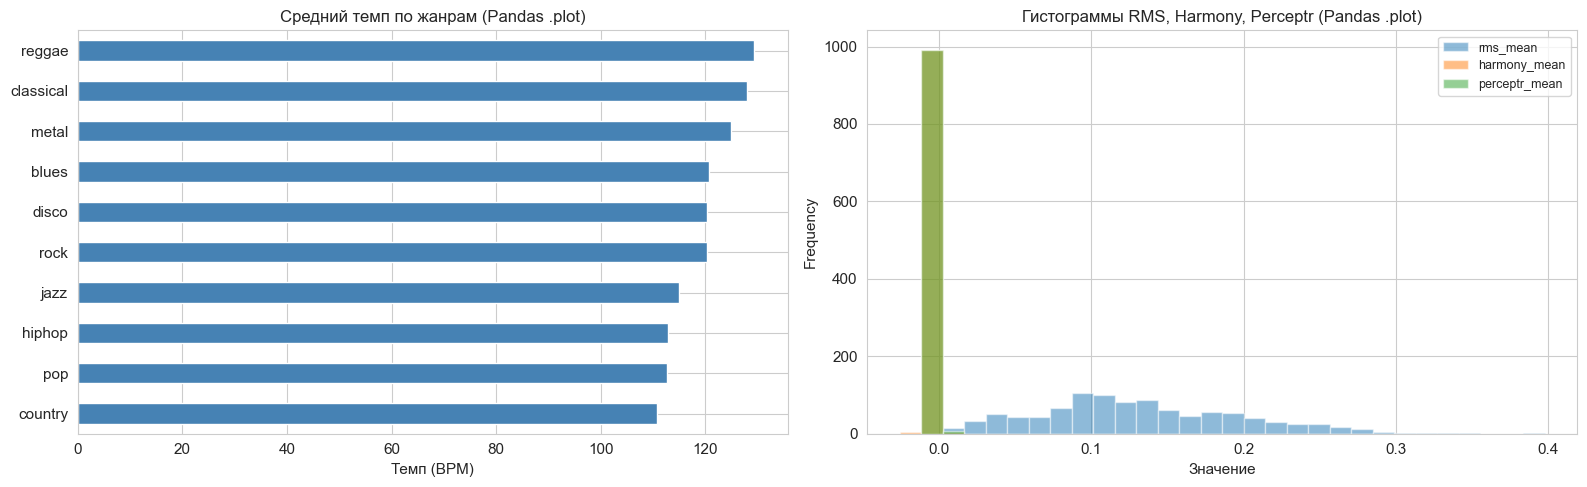

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot через pandas
df.groupby('label')['tempo'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Средний темп по жанрам (Pandas .plot)', fontsize=12)
axes[0].set_xlabel('Темп (BPM)')
axes[0].set_ylabel('')

# Гистограмма через pandas
df[['rms_mean', 'harmony_mean', 'perceptr_mean']].plot(
    kind='hist', bins=30, alpha=0.5, ax=axes[1], edgecolor='white'
)
axes[1].set_title('Гистограммы RMS, Harmony, Perceptr (Pandas .plot)', fontsize=12)
axes[1].set_xlabel('Значение')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Интерпретация:** Pandas .plot() позволяет быстро строить графики с минимумом кода. Метод удобен для экспресс-анализа, но для тонкой настройки оформления всё равно потребуется Matplotlib API.

---
## Выводы

Провели разведочный анализ датасета GTZAN (1000 треков, 10 жанров, 57 числовых признаков) с помощью Matplotlib, Seaborn, Plotly и Pandas. Ниже — главные факты, которые удалось вытащить из данных.

### Главные находки о признаках

**Многие признаки дублируют друг друга.** Четыре спектральных признака (`spectral_centroid`, `rolloff`, `spectral_bandwidth`, `zero_crossing_rate`) все описывают «яркость» звука — между ними почти одинаковая информация (корреляции до 0.98). Их можно было бы оставить один вместо четырёх.

**Некоторые пары — зеркальны.** `mfcc2` ведёт себя как «перевёрнутый» spectral_centroid (r = −0.94). А `mfcc1` ≈ логарифм `rms_mean` — pairplot показал между ними идеальную логарифмическую кривую. Это логично: `mfcc1` по определению — логарифм громкости, а `rms` — сама громкость.

**Tempo стоит особняком.** Почти не коррелирует ни с одним другим признаком. При этом признак **не совсем непрерывный**: `librosa` выдаёт стандартные значения (123 BPM у 94 треков из 1000, 129 и 117 — у 79). То есть темп ведёт себя скорее как набор из 10–20 частых значений.

**MFCC связаны «через один».** Коэффициенты одинаковой чётности (чётный с чётным, нечётный с нечётным) умеренно коррелируют: `mfcc6`↔`mfcc8` = 0.84, `mfcc7`↔`mfcc9` = 0.79. Именно поэтому на тепловой карте видны «зеркальные» профили pop и metal по MFCC.

**Два трека-выброса.** `pop.00062.wav` — самый громкий в датасете (rms = 0.40). `reggae.00086.wav` — аномально высокая яркость для reggae (centroid = 4435). Стоит проверить в следующей лабе по очистке данных.

### Главные находки о жанрах

**classical легче всего отделить.** Он тише, темнее и глухее остальных: минимум по rms (0.03) и spectral_centroid (1345). На всех графиках стоит в стороне.

**pop — самый громкий и яркий**, а не metal (как можно было бы подумать). Причина — современный мастеринг с компрессией, который «подтягивает» громкость. Metal идёт вторым, но лидирует по `zero_crossing_rate` (шумность).

**pop и metal — антиподы в MFCC.** Там, где у одного плюс, у другого минус, и наоборот, причём стабильно на MFCC 3–10. Такая устойчивая противоположность — очень надёжный сигнал для классификатора.

**Бимодальность MFCC = смешение жанров, а не природа признака.** На общей гистограмме MFCC 7–10 два пика, но отдельно каждый жанр — одногорбый. Два пика появляются просто потому, что жанры имеют разные типичные значения, и их сумма даёт двухгорбую картину.

**Внутренняя неоднородность у disco, hiphop и country.** У этих жанров видны **два пика** на некоторых MFCC — значит, внутри жанра есть подстили с разным тембром. Метки GTZAN на этих жанрах не полностью однородны.

**Середняки часто путают.** blues, country, rock — у них нет ярких экстремумов ни по одному признаку, поэтому классификаторы будут их смешивать.

### Что это значит для следующих лаб

- **Можно смело удалить** `rolloff_mean` (дубль centroid), `mfcc2_mean` (его зеркало), один из `spectral_bandwidth`/`centroid`, возможно `mfcc1_mean` (дубль rms). Останется ~52 признака из 57 практически без потери информации — для линейных моделей это критично, для деревьев (Random Forest, XGBoost) не важно.
- **Дисперсии `*_var`** сильно скошены — их стоит логарифмировать или применить преобразование мощности (например, Yeo-Johnson), иначе линейные модели будут работать хуже.
- **Для disco, hiphop, country** лучше выбирать модели, которые допускают несколько «центров» внутри класса (деревья, Random Forest, KNN). Модели с допущением «один центр на класс» (GaussianNB, LDA) на этих жанрах просядут.
- **Ставка на признаки:** `spectral_centroid`, `rms`, `mfcc1–10` — сильные, хорошо разделяют классы. `tempo` и хроматограммы — слабые по отдельности, но могут помочь в ансамбле.
- **Два подозрительных трека** нужно проверить на этапе очистки.

### Какой инструмент для чего

| Когда нужно | Что использовать |
|---|---|
| Точный контроль над графиком для отчёта | **Matplotlib** |
| Быстрый статистический EDA (heatmap, violin, pairplot) | **Seaborn** |
| Интерактивно исследовать данные (hover, зум, фильтры) | **Plotly** |
| Черновик прямо из DataFrame в одну строку | **Pandas `.plot()`** |

Для публикации — Matplotlib/Seaborn, для презентации — Plotly, для быстрого чернового анализа — Pandas.